# 03 — TCN WFO Colab Trial

Colab/A100/MPS-friendly replacement trial for the static TCN notebook.

This notebook mirrors the checks used in `02_mamba_v1`:

- Walk-forward retraining, expanding window by default, every 3 months.
- 48-hour embargo between train and validation/OOS fold start.
- Fold-local validation percentile signal for trading, plus raw probability audit files.
- Trading parameters selected only on the validation window, `2023-06-01 → 2024-05-31`.
- OOS is fixed to `2024-06-01 → 2026-05-31 23:00:00` and is used only for final reporting.
- Same fee/fill/short-funding model as the other notebooks.
- Standard MAS artifacts: `oos_probs.npy`, `oos_pdown.npy`, `oos_index.npy`, `wfo_probs.npy`, `wfo_pdown.npy`, `wfo_index.npy`, `results.json`.

After a good Colab run, copy `artifacts_tcn_wfo/` into `artifacts/notebooks_v2/03_tcn/`, then rerun `06_multi_agent_v1.ipynb`.


## 0 · Environment

In [1]:
# Colab setup. In local Jupyter this cell is harmless except for the install.
!pip -q install pyarrow scikit-learn matplotlib seaborn 2>/dev/null

import calendar, itertools, json, math, random, shutil, time, warnings, zipfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("seaborn-whitegrid")
mpl.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 10, "axes.titlesize": 11, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})
ACCENT = "#F7931A"; BLUE = "#2962FF"; GREY = "#9E9E9E"; RED = "#EF5350"; GREEN = "#26A69A"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)


Device: cuda


## 1 · Configuration

In [4]:
# ── Data source ────────────────────────────────────────────────────────────────
USE_DRIVE = True
DRIVE_DIR = "/content/drive/MyDrive/hmats_data"
LOCAL_PARQUET = "/content/BTCUSDT_1h_unified.parquet"

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive mount skipped:", e)

DATA_PATH = Path(DRIVE_DIR) / "BTCUSDT_1h_unified.parquet" if USE_DRIVE else Path(LOCAL_PARQUET)
ARTS_DIR = Path("/content/artifacts_tcn_wfo")
ARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Unified split discipline ─────────────────────────────────────────────────
GRID_VAL_START = pd.Timestamp("2023-06-01")
GRID_VAL_END = pd.Timestamp("2024-05-31 23:00:00")
OOS_START = pd.Timestamp("2024-06-01")
OOS_END = pd.Timestamp("2026-05-31 23:00:00")
WFO_START = GRID_VAL_START
RETRAIN_MONTHS = 3
WFO_SCHEME = "expanding"        # same default as Mamba; "sliding" available
TRAIN_WINDOW_MONTHS = 36        # used when WFO_SCHEME='sliding'
EMBARGO_H = 48                  # > 24h TBM label horizon
VAL_FRAC = 0.15

# ── TCN / label spec ─────────────────────────────────────────────────────────
TBM_VOL_WINDOW = 24
TBM_MULT = 2.0
TBM_VERT_H = 24
FRAC_D = 0.4
FFD_THRES = 1e-4
SEQ_LEN = 48
TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL = 3
TCN_DROPOUT = 0.20
EPOCHS = 80
BATCH_SIZE = 256
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10
LAMBDA_VOL = 0.50
AUX_FWD_H = 6

# ── Execution model, identical convention to notebooks_v2 ───────────────────
MAKER_FEE = 0.0
SPOT_TAKER_FEE = 0.0005
FUTURES_TAKER_FEE = 0.0005
BUFFER = 0.0005
SHORT_FUNDING_H = 0.0000077
MIN_SL = 0.010
ANN = np.sqrt(24 * 365)

# Same compact feature family as static 03_tcn_v1 for comparability.
LGBM_CORE = ["stoch_k_14", "ret_2h", "rsi_divergence", "close_vs_sma_7", "bear_streak",
             "close_vs_s1", "macd_hist_5_13", "ad_z_48h", "ret_3h"]
V1_EXTRA = ["ret_1h", "rsi_14", "vol_ratio_24h", "bb_position_20", "hour_sin", "hour_cos",
            "atr_14_pct", "hurst_168h", "trend_score", "close_vs_sma_50", "ma_bull_score"]
V4_FEATURES = ["close_vs_true_vwap", "hurst_24h", "hurst_72h", "tfi_pct", "tfi_z_24h",
               "bb_width_pct", "sideways_flag"]
STRUCT_FEATURES = ["liq_vwap_dev_24h", "volat_atr_20_pct", "mtf_alignment", "mtf_h4_rsi"]
BASE_FEATURES = LGBM_CORE + V1_EXTRA + V4_FEATURES + STRUCT_FEATURES
FFD_COL = "ffd_log_price"

TRADING_GRID = {
    "signal_threshold": [0.08, 0.10, 0.13, 0.15, 0.18, 0.22, 0.26],
    "entry_atr_mult": [0.0, 0.3, 0.6],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5],
    "tp_atr_mult": [1.5, 2.0, 2.5, 3.0],
    "min_hold": [6, 12],
    "max_hold": [24, 48, 72],
    "cooldown": [2, 3, 6],
    "trade_direction": ["both", "long_only", "short_only"],
}

print(f"Artifacts -> {ARTS_DIR}")
print(f"WFO: {WFO_SCHEME}, step={RETRAIN_MONTHS}mo, grid-val={GRID_VAL_START.date()}->{GRID_VAL_END.date()}")
print(f"OOS: {OOS_START.date()}->{OOS_END.date()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts -> /content/artifacts_tcn_wfo
WFO: expanding, step=3mo, grid-val=2023-06-01->2024-05-31
OOS: 2024-06-01->2026-05-31


## 2 · Load Unified Parquet And Guards

In [5]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found. Upload/copy BTCUSDT_1h_unified.parquet first.")

df = pd.read_parquet(DATA_PATH)
df.index = df.index.tz_localize(None) if getattr(df.index, "tz", None) else df.index
df = df.sort_index()

future_name_hits = [c for c in df.columns if any(tok in c.lower() for tok in [
    "future", "lead", "next_", "target", "label", "y_"
])]
print(f"Data: {df.shape[0]:,} bars x {df.shape[1]:,} cols | {df.index.min()} -> {df.index.max()}")
print("Future/label-name guard hits:", future_name_hits[:20], "| count:", len(future_name_hits))

missing = [f for f in BASE_FEATURES if f not in df.columns]
if missing:
    raise RuntimeError(f"Missing TCN features: {missing}")
print(f"Base features present: {len(BASE_FEATURES)}")


Data: 77,036 bars x 291 cols | 2017-08-17 04:00:00 -> 2026-05-31 23:00:00
Future/label-name guard hits: ['weekly_mom_accel', 'label', 'taker_buy_price', 'struct_body_ratio'] | count: 4
Base features present: 31


## 3 · Fractional Differentiation And TBM Labels

In [6]:
log_close = np.log(df["close"])

def _ffd_weights(d, thres=1e-4):
    w = [1.0]; k = 1
    while True:
        wk = -w[-1] * (d - k + 1) / k
        w.append(wk); k += 1
        if abs(wk) < thres:
            break
    return np.array(w[::-1])

def _ffd_series(series, d, thres=1e-4):
    w = _ffd_weights(d, thres)
    out = np.full(len(series), np.nan)
    vals = series.values
    for i in range(len(w) - 1, len(series)):
        out[i] = float(np.dot(w, vals[i - len(w) + 1:i + 1]))
    return pd.Series(out, index=series.index, name=FFD_COL)

df[FFD_COL] = _ffd_series(log_close, FRAC_D, FFD_THRES)
ALL_FEATURES = BASE_FEATURES + [FFD_COL]

log_rets = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()
close_vals = df["close"].values
vol_vals = rolling_vol.values
n = len(df)
y_dir = np.full(n, np.nan, dtype=np.float32)
y_fwd_vol = np.full(n, np.nan, dtype=np.float32)

t0 = time.time()
for i in range(n):
    if np.isnan(vol_vals[i]) or vol_vals[i] == 0:
        continue
    sigma = vol_vals[i] * close_vals[i]
    up = close_vals[i] + TBM_MULT * sigma
    dn = close_vals[i] - TBM_MULT * sigma
    end_j = min(i + TBM_VERT_H, n)
    for j in range(i + 1, end_j):
        if close_vals[j] >= up:
            y_dir[i] = 1
            break
        if close_vals[j] <= dn:
            y_dir[i] = 0
            break
    else:
        y_dir[i] = -1
    fwd = log_rets.values[i + 1:i + 1 + AUX_FWD_H]
    if len(fwd):
        y_fwd_vol[i] = float(np.std(fwd))

df["y_dir"] = y_dir
df["y_fwd_vol"] = y_fwd_vol
valid_dir = df["y_dir"].isin([0, 1])
print(f"TBM labels built in {time.time()-t0:.1f}s")
print(df.loc[valid_dir, "y_dir"].value_counts(normalize=True).sort_index().rename({0:"down",1:"up"}))


TBM labels built in 2.2s
y_dir
down   0.4889
up     0.5111
Name: proportion, dtype: float64


## 4 · Model Helpers

In [7]:
class CausalBlock(nn.Module):
    def __init__(self, in_c, out_c, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.Conv1d(in_c, out_c, kernel, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_c, out_c, kernel, dilation=dilation, padding=pad)
        self.skip = nn.Conv1d(in_c, out_c, 1) if in_c != out_c else None
        self.drop = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(out_c)
        self.norm2 = nn.LayerNorm(out_c)

    def forward(self, x):
        r = self.skip(x) if self.skip is not None else x
        y = self.conv1(x)[..., :x.shape[-1]]
        y = F.relu(self.norm1(y.transpose(1, 2)).transpose(1, 2))
        y = self.drop(y)
        y = self.conv2(y)[..., :x.shape[-1]]
        y = F.relu(self.norm2(y.transpose(1, 2)).transpose(1, 2))
        y = self.drop(y)
        return F.relu(y + r)

class TCNMultiTask(nn.Module):
    def __init__(self, n_feat, channels, kernel, dropout, n_classes=2):
        super().__init__()
        layers = []
        in_c = n_feat
        for i, out_c in enumerate(channels):
            layers.append(CausalBlock(in_c, out_c, kernel, 2 ** i, dropout))
            in_c = out_c
        self.tcn = nn.Sequential(*layers)
        self.cls_head = nn.Linear(channels[-1], n_classes)
        self.vol_head = nn.Linear(channels[-1], 1)

    def forward(self, x):
        h = self.tcn(x.transpose(1, 2))
        last = h[:, :, -1]
        return self.cls_head(last), self.vol_head(last).squeeze(-1)

def make_seqs(X, yd, yv, seq_len=SEQ_LEN):
    Xs, Yd, Yv = [], [], []
    for i in range(seq_len - 1, len(X)):
        if yd[i] not in (0, 1):
            continue
        Xs.append(X[i - seq_len + 1:i + 1])
        Yd.append(int(yd[i]))
        Yv.append(yv[i] if not np.isnan(yv[i]) else 0.0)
    if not Xs:
        return None
    return np.stack(Xs).astype(np.float32), np.array(Yd, np.int64), np.array(Yv, np.float32)

def _predict_proba(model, X_np, batch=2048):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch):
            xb = torch.from_numpy(X_np[s:s+batch]).to(DEVICE)
            logits, _ = model(xb)
            out.append(torch.softmax(logits, -1).cpu().numpy())
    return np.concatenate(out, axis=0)

def _fold_percentile_score(raw_pup, val_ref):
    ref = np.sort(np.asarray(val_ref)[np.isfinite(val_ref)])
    if len(ref) == 0:
        return np.full_like(raw_pup, np.nan, dtype=np.float32)
    return (np.searchsorted(ref, raw_pup, side="right") / len(ref)).astype(np.float32)

def train_fold(Xtr, ytr_d, ytr_v, Xvl, yvl_d, yvl_v):
    g = torch.Generator(); g.manual_seed(SEED)
    model = TCNMultiTask(len(ALL_FEATURES), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    counts = np.bincount(ytr_d, minlength=2)
    weights = torch.tensor(1.0 / np.maximum(counts, 1), dtype=torch.float32).to(DEVICE)
    weights /= weights.sum()
    cls_crit = nn.CrossEntropyLoss(weight=weights)
    vol_crit = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr_d), torch.from_numpy(ytr_v)),
                              BATCH_SIZE, shuffle=True, drop_last=True, generator=g)
    val_loader = DataLoader(TensorDataset(torch.from_numpy(Xvl), torch.from_numpy(yvl_d), torch.from_numpy(yvl_v)),
                            BATCH_SIZE, shuffle=False)
    opt = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, epochs=EPOCHS, steps_per_epoch=max(1, len(train_loader)))
    best, best_state, best_ep, best_auc = 1e9, None, 0, np.nan
    for ep in range(1, EPOCHS + 1):
        model.train()
        for xb, yd, yv in train_loader:
            xb, yd, yv = xb.to(DEVICE), yd.to(DEVICE), yv.to(DEVICE)
            opt.zero_grad()
            logits, vol = model(xb)
            loss = cls_crit(logits, yd) + LAMBDA_VOL * vol_crit(vol, yv)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
        model.eval(); vl, ps, ys = 0.0, [], []
        with torch.no_grad():
            for xb, yd, yv in val_loader:
                xb, yd, yv = xb.to(DEVICE), yd.to(DEVICE), yv.to(DEVICE)
                logits, vol = model(xb)
                vl += (cls_crit(logits, yd) + LAMBDA_VOL * vol_crit(vol, yv)).item()
                ps.append(torch.softmax(logits, -1)[:, 1].cpu().numpy())
                ys.append(yd.cpu().numpy())
        vl /= max(len(val_loader), 1)
        ycat = np.concatenate(ys); pcat = np.concatenate(ps)
        auc = roc_auc_score(ycat, pcat) if len(set(ycat)) > 1 else np.nan
        if vl < best:
            best, best_auc, best_ep = vl, auc, ep
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep - best_ep >= PATIENCE:
            break
    model.load_state_dict(best_state)
    return model, {"best_val_loss": float(best), "best_val_auc": float(best_auc), "best_epoch": int(best_ep)}

N_FEATURES = len(ALL_FEATURES)
n_params = sum(p.numel() for p in TCNMultiTask(N_FEATURES, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
rf = 1 + 2 * (TCN_KERNEL - 1) * sum(2 ** i for i in range(len(TCN_CHANNELS)))
print(f"TCN params={n_params:,}, features={N_FEATURES}, receptive_field={rf}")


TCN params=96,003, features=32, receptive_field=61


## 5 · Walk-Forward Training

In [8]:
feat_ok = df[ALL_FEATURES].notna().all(axis=1)
probs_raw = np.full(len(df), np.nan, dtype=np.float32)
probs = np.full(len(df), np.nan, dtype=np.float32)
fold_log = []
last_model = None

anchors = []
d = WFO_START
while d <= OOS_END:
    anchors.append(d)
    d += pd.DateOffset(months=RETRAIN_MONTHS)

t_all = time.time()
for fi, start in enumerate(anchors, 1):
    end = min(start + pd.DateOffset(months=RETRAIN_MONTHS), OOS_END + pd.Timedelta(hours=1))
    if WFO_SCHEME == "expanding":
        tr_start = df.index.min()
    elif WFO_SCHEME == "sliding":
        tr_start = start - pd.DateOffset(months=TRAIN_WINDOW_MONTHS)
    else:
        raise ValueError(WFO_SCHEME)
    tr_end = start - pd.Timedelta(hours=EMBARGO_H)
    train_mask = (df.index >= tr_start) & (df.index < tr_end) & feat_ok & valid_dir
    train_df = df[train_mask].copy()
    if len(train_df) < 4000:
        print(f"[{fi:02d}] skip {start.date()} insufficient train rows={len(train_df)}")
        continue
    cut = int(len(train_df) * (1 - VAL_FRAC))
    tri, vli = train_df.index[:cut], train_df.index[cut:]
    qt = QuantileTransformer(output_distribution="normal", n_quantiles=min(1000, len(tri)), random_state=SEED)
    qt.fit(np.nan_to_num(df.loc[tri, ALL_FEATURES].values.astype(np.float32)))

    def seqs(idx):
        sub = df.loc[idx]
        X = qt.transform(np.nan_to_num(sub[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)
        return make_seqs(X, sub["y_dir"].values, sub["y_fwd_vol"].values)

    s_tr, s_vl = seqs(tri), seqs(vli)
    if s_tr is None or s_vl is None or len(np.unique(s_tr[1])) < 2:
        print(f"[{fi:02d}] skip {start.date()} bad sequence/class coverage")
        continue
    model, meta = train_fold(*s_tr, *s_vl)
    last_model = model

    val_probs = _predict_proba(model, s_vl[0])[:, 1]
    pred_start = start - pd.Timedelta(hours=SEQ_LEN - 1)
    block = df[(df.index >= pred_start) & (df.index < end) & feat_ok].copy()
    Xb = qt.transform(np.nan_to_num(block[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)
    Xo, bar_idx = [], []
    for i in range(SEQ_LEN - 1, len(Xb)):
        Xo.append(Xb[i - SEQ_LEN + 1:i + 1]); bar_idx.append(block.index[i])
    Xo = np.stack(Xo).astype(np.float32)
    pred_raw = _predict_proba(model, Xo)[:, 1]
    pred_idx = pd.DatetimeIndex(bar_idx)
    keep = (pred_idx >= start) & (pred_idx < end)
    rows = df.index.get_indexer(pred_idx[keep])
    probs_raw[rows] = pred_raw[keep]
    probs[rows] = _fold_percentile_score(pred_raw[keep], val_probs)

    fold_log.append({"fold": fi, "start": str(start), "end": str(end),
                     "train_rows": int(len(train_df)), **meta})
    print(f"[{fi:02d}/{len(anchors)}] {start.date()}->{(end-pd.Timedelta(hours=1)).date()} "
          f"train={len(train_df):,} val_auc={meta['best_val_auc']:.3f} "
          f"best_ep={meta['best_epoch']} elapsed={(time.time()-t_all)/60:.1f}m", flush=True)

if last_model is not None:
    torch.save(last_model.state_dict(), ARTS_DIR / "model_lastfold.pt")

oos_m = (df.index >= OOS_START) & (df.index <= OOS_END) & np.isfinite(probs_raw)
auc_m = oos_m & df["y_dir"].isin([0, 1]).values
auc_oos_raw = roc_auc_score((df.loc[auc_m, "y_dir"].values == 1).astype(int), probs_raw[auc_m])
auc_oos_signal = roc_auc_score((df.loc[auc_m, "y_dir"].values == 1).astype(int), probs[auc_m])
print(f"WFO done in {(time.time()-t_all)/60:.1f} min | folds={len(fold_log)}")
print(f"OOS AUC raw={auc_oos_raw:.4f} | signal-rank={auc_oos_signal:.4f} | OOS probs={oos_m.sum():,}")

oos_probs_series = pd.Series(probs, index=df.index)[(df.index >= OOS_START) & (df.index <= OOS_END)]
oos_raw_probs_series = pd.Series(probs_raw, index=df.index)[(df.index >= OOS_START) & (df.index <= OOS_END)]
oos_df = df.loc[oos_probs_series.index].copy()


[01/12] 2023-06-01->2023-08-31 train=44,382 val_auc=0.512 best_ep=15 elapsed=0.9m
[02/12] 2023-09-01->2023-11-30 train=46,197 val_auc=0.534 best_ep=15 elapsed=1.7m
[03/12] 2023-12-01->2024-02-29 train=47,984 val_auc=0.531 best_ep=18 elapsed=2.6m
[04/12] 2024-03-01->2024-05-31 train=49,931 val_auc=0.538 best_ep=16 elapsed=3.5m
[05/12] 2024-06-01->2024-08-31 train=51,894 val_auc=0.549 best_ep=16 elapsed=4.4m
[06/12] 2024-09-01->2024-11-30 train=53,875 val_auc=0.556 best_ep=16 elapsed=5.4m
[07/12] 2024-12-01->2025-02-28 train=55,764 val_auc=0.543 best_ep=15 elapsed=6.3m
[08/12] 2025-03-01->2025-05-31 train=57,692 val_auc=0.562 best_ep=17 elapsed=7.4m
[09/12] 2025-06-01->2025-08-31 train=59,660 val_auc=0.555 best_ep=17 elapsed=8.5m
[10/12] 2025-09-01->2025-11-30 train=61,661 val_auc=0.552 best_ep=18 elapsed=9.7m
[11/12] 2025-12-01->2026-02-28 train=63,561 val_auc=0.558 best_ep=21 elapsed=11.1m
[12/12] 2026-03-01->2026-05-31 train=65,471 val_auc=0.530 best_ep=13 elapsed=12.1m
WFO done in 12

## 6 · Trading Grid Search On Validation Only

In [9]:
def _run_backtest(prob, close, high, low, atr, *, long_threshold, short_threshold,
                  entry_atr_mult, sl_atr_mult, tp_atr_mult, min_hold, max_hold, cooldown,
                  trade_direction="both", with_fees=True):
    n = len(close); eq = np.ones(n); cur = 1.0; trades = []
    in_pos = False; direction = None; entry_px = sl_px = tp_px = pos_eq = entry_fee = 0.0
    hold = cd = 0; funding = 0.0; pending = None
    for i in range(n):
        lo, hi, px = low[i], high[i], close[i]
        if in_pos:
            hold += 1
            if direction == "short":
                funding += SHORT_FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == "long" else 1 + (entry_px - px) / entry_px)
            ex, xpx, xf = False, 0.0, 0.0
            if hold >= min_hold:
                if direction == "long":
                    if lo <= sl_px: xpx, ex, xf = sl_px, True, SPOT_TAKER_FEE if with_fees else 0.0
                    elif hi >= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, SPOT_TAKER_FEE if with_fees else 0.0
                else:
                    if hi >= sl_px: xpx, ex, xf = sl_px, True, FUTURES_TAKER_FEE if with_fees else 0.0
                    elif lo <= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, FUTURES_TAKER_FEE if with_fees else 0.0
            if ex:
                gross = ((xpx-entry_px)/entry_px if direction == "long" else (entry_px-xpx)/entry_px)
                net = gross - (entry_fee + xf if with_fees else 0.0) - funding
                cur = pos_eq * (1.0 + net); eq[i] = cur
                trades.append({"direction": direction, "net": net, "hold": hold})
                in_pos, cd, funding = False, cooldown, 0.0
        elif pending is not None:
            d, lim, ps, pt = pending
            if d == "long":
                fill = lo <= lim + BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.0)
            else:
                fill = hi >= lim - BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.0)
            entry_px, sl_px, tp_px, entry_fee = (lim if fill else px), ps, pt, ef
            direction, in_pos, pos_eq, hold, funding = d, True, cur, 0, 0.0
            pending = None; eq[i] = cur
        elif cd > 0:
            cd -= 1; eq[i] = cur
        elif not np.isnan(prob[i]) and i + 1 < n:
            a = max(atr[i], MIN_SL)
            if trade_direction in ("both", "long_only") and prob[i] > long_threshold:
                pending = ("long", px*(1-entry_atr_mult*a), px*(1-sl_atr_mult*a), px*(1+tp_atr_mult*a))
            elif trade_direction in ("both", "short_only") and prob[i] < short_threshold:
                pending = ("short", px*(1+entry_atr_mult*a), px*(1+sl_atr_mult*a), px*(1-tp_atr_mult*a))
            eq[i] = cur
        else:
            eq[i] = cur
    if in_pos:
        gross = ((px-entry_px)/entry_px if direction == "long" else (entry_px-px)/entry_px)
        taker = SPOT_TAKER_FEE if direction == "long" else FUTURES_TAKER_FEE
        net = gross - (entry_fee + (taker if with_fees else 0.0)) - funding
        cur = pos_eq * (1.0 + net); eq[-1] = cur
    return eq, pd.DataFrame(trades)

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * ANN)

def _sortino(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    neg = r[r < 0]
    d = neg.std(ddof=1) if len(neg) > 1 else 1e-12
    return float(r.mean() / (d + 1e-12) * ANN)

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

gv_m = (df.index >= GRID_VAL_START) & (df.index <= GRID_VAL_END)
gv_df = df[gv_m].copy()
gv_p = probs[gv_m]
finite_ratio = np.isfinite(gv_p).mean()
print(f"Grid-val finite probability ratio: {finite_ratio:.1%}")
if finite_ratio < 0.50:
    raise RuntimeError("Grid-val probabilities are too sparse. Check WFO_START/fold generation.")

rows = []
t0 = time.time()
for vals in itertools.product(*TRADING_GRID.values()):
    raw = dict(zip(TRADING_GRID.keys(), vals))
    if raw["max_hold"] < raw["min_hold"]:
        continue
    t = raw.pop("signal_threshold")
    p = {**raw, "long_threshold": 0.5 + t, "short_threshold": 0.5 - t}
    eq, tr = _run_backtest(gv_p, gv_df["close"].values, gv_df["high"].values,
                           gv_df["low"].values, gv_df["atr_14_pct"].values,
                           with_fees=True, **p)
    ntr = len(tr); nl = int((tr["direction"] == "long").sum()) if ntr else 0
    ns = int((tr["direction"] == "short").sum()) if ntr else 0
    if not (40 <= ntr <= 500):
        continue
    if _maxdd(eq) < -0.35:
        continue
    rows.append({**p, "ret": float(eq[-1]-1), "sharpe": _sharpe(eq), "sortino": _sortino(eq),
                 "maxdd": _maxdd(eq), "n_trades": ntr, "n_long": nl, "n_short": ns})

grid_df = pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)
if grid_df.empty:
    raise RuntimeError("No valid trading configs.")

INT = {"min_hold", "max_hold", "cooldown"}
BEST = {k: (int(grid_df.iloc[0][k]) if k in INT else grid_df.iloc[0][k] if k == "trade_direction"
            else float(grid_df.iloc[0][k]))
        for k in ["long_threshold", "short_threshold", "entry_atr_mult", "sl_atr_mult",
                  "tp_atr_mult", "min_hold", "max_hold", "cooldown", "trade_direction"]}
print(f"Grid done in {time.time()-t0:.0f}s | valid configs={len(grid_df):,}")
print("BEST:", BEST)
display(grid_df.head(12))


Grid-val finite probability ratio: 100.0%
Grid done in 174s | valid configs=12,669
BEST: {'long_threshold': 0.58, 'short_threshold': 0.42, 'entry_atr_mult': 0.0, 'sl_atr_mult': 1.0, 'tp_atr_mult': 2.5, 'min_hold': 6, 'max_hold': 24, 'cooldown': 2, 'trade_direction': 'long_only'}


,entry_atr_mult,sl_atr_mult,tp_atr_mult,min_hold,max_hold,cooldown,trade_direction,long_threshold,short_threshold,ret,sharpe,sortino,maxdd,n_trades,n_long,n_short
0,0.0000,1.0000,2.5000,6,24,2,long_only,0.5800,0.4200,2.5867,3.6533,3.9929,-0.1074,369,369,0
1,0.0000,1.0000,3.0000,6,24,3,long_only,0.5800,0.4200,2.4953,3.6213,3.8874,-0.0983,342,342,0
2,0.0000,1.0000,3.0000,12,24,6,long_only,0.6500,0.3500,2.6766,3.5775,3.5769,-0.1313,259,259,0
3,0.0000,1.0000,3.0000,12,24,3,long_only,0.7200,0.2800,2.3394,3.5575,3.5212,-0.1268,261,261,0
4,0.0000,1.0000,2.0000,6,72,6,long_only,0.7200,0.2800,1.7250,3.5500,3.4725,-0.1111,245,245,0
5,0.0000,1.0000,3.0000,6,72,2,long_only,0.5800,0.4200,2.4985,3.4850,4.1139,-0.1189,269,269,0
6,0.0000,1.0000,3.0000,6,24,3,long_only,0.6000,0.4000,2.3259,3.4805,3.6416,-0.1178,334,334,0
7,0.0000,1.0000,2.5000,6,72,2,long_only,0.5800,0.4200,2.4761,3.4634,3.8505,-0.1229,303,303,0
8,0.0000,1.0000,2.5000,6,72,2,long_only,0.6000,0.4000,2.4340,3.4565,3.8207,-0.1554,299,299,0
9,0.0000,1.0000,2.5000,6,24,6,long_only,0.7600,0.2400,1.5328,3.4562,3.1495,-0.1215,250,250,0


## 7 · OOS Backtest And Figures

                       Trades     Win   Return  Sharpe   MaxDD
--------------------------------------------------------------
With fees                 740   40.9%  +148.0%   1.243  -22.0%
Zero-fee                  740   41.6%  +232.9%   1.650  -21.1%


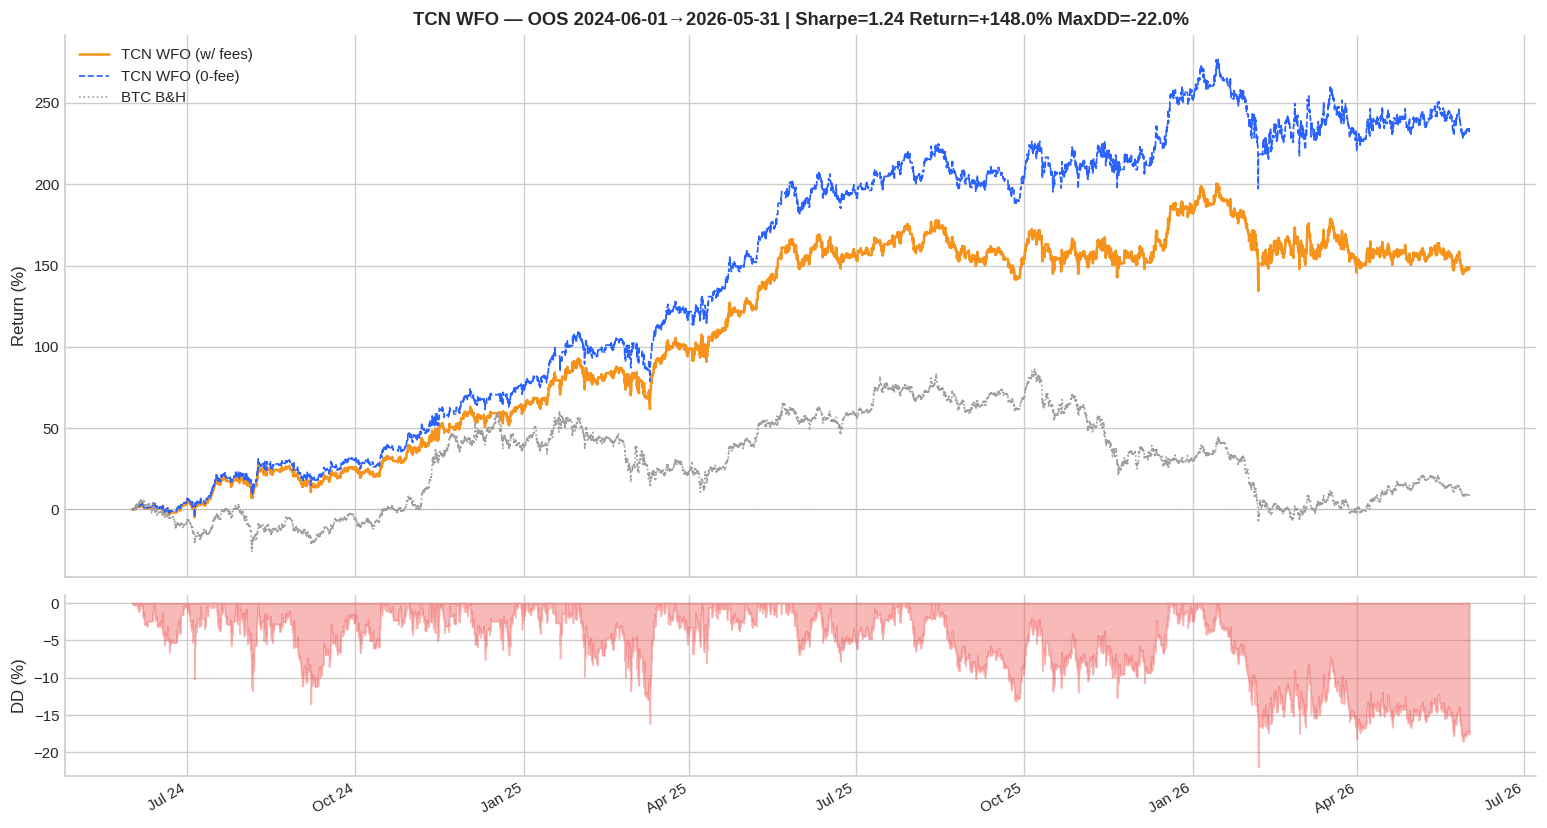

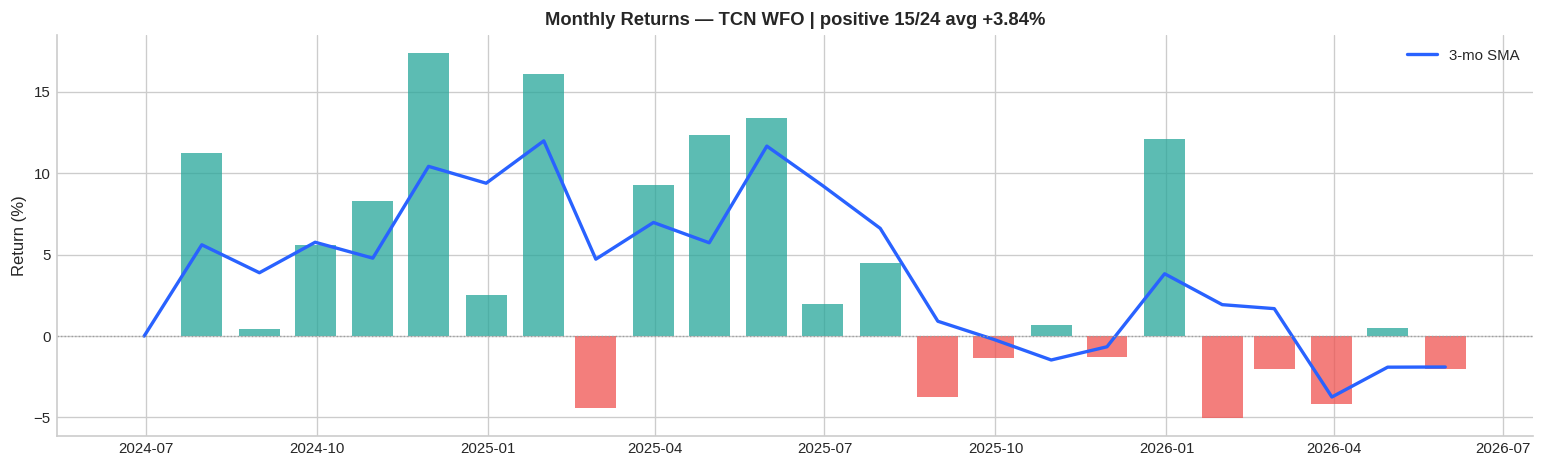

In [10]:
o_p = oos_probs_series.values
o_idx = oos_probs_series.index
o_df = df.loc[o_idx].copy()

eq_fees, TF = _run_backtest(o_p, o_df["close"].values, o_df["high"].values, o_df["low"].values,
                            o_df["atr_14_pct"].values, with_fees=True, **BEST)
eq_0fee, T0 = _run_backtest(o_p, o_df["close"].values, o_df["high"].values, o_df["low"].values,
                            o_df["atr_14_pct"].values, with_fees=False, **BEST)
TF = TF if len(TF) else pd.DataFrame(columns=["direction", "net", "hold"])
T0 = T0 if len(T0) else pd.DataFrame(columns=["direction", "net", "hold"])

def _bt_metrics(eq, t):
    wr = float((t["net"] > 0).mean()) if len(t) else 0.0
    nl = int((t["direction"] == "long").sum()) if len(t) else 0
    ns = int((t["direction"] == "short").sum()) if len(t) else 0
    return {"n_trades": len(t), "n_long": nl, "n_short": ns, "win_rate": round(wr, 4),
            "total_ret": round(float(eq[-1]-1), 4), "sharpe": round(_sharpe(eq), 4),
            "sortino": round(_sortino(eq), 4), "maxdd": round(_maxdd(eq), 4)}

print(f'{"":22}{"Trades":>7}{"Win":>8}{"Return":>9}{"Sharpe":>8}{"MaxDD":>8}')
print("-" * 62)
for lbl, eq, t in [("With fees", eq_fees, TF), ("Zero-fee", eq_0fee, T0)]:
    m = _bt_metrics(eq, t)
    print(f'{lbl:22}{m["n_trades"]:>7}{m["win_rate"]:>8.1%}{m["total_ret"]:>+9.1%}'
          f'{m["sharpe"]:>8.3f}{m["maxdd"]:>8.1%}')

bh = (o_df["close"].values / o_df["close"].iloc[0] - 1) * 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[3, 1], sharex=True)
ax1.plot(o_idx, (eq_fees - 1) * 100, color=ACCENT, lw=1.5, label="TCN WFO (w/ fees)")
ax1.plot(o_idx, (eq_0fee - 1) * 100, color=BLUE, lw=1.0, ls="--", label="TCN WFO (0-fee)")
ax1.plot(o_idx, bh, color=GREY, lw=1.0, ls=":", label="BTC B&H")
ax1.axhline(0, color=GREY, lw=0.6, ls=":")
ax1.set_ylabel("Return (%)"); ax1.legend()
ax1.set_title(f"TCN WFO — OOS {OOS_START.date()}→{o_idx[-1].date()} | "
              f"Sharpe={_sharpe(eq_fees):.2f} Return={eq_fees[-1]-1:+.1%} MaxDD={_maxdd(eq_fees):.1%}",
              fontweight="bold")
pk = np.maximum.accumulate(eq_fees); dd = (eq_fees - pk) / pk * 100
ax2.fill_between(o_idx, dd, 0, color=RED, alpha=0.4)
ax2.set_ylabel("DD (%)")
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
fig.tight_layout(); fig.savefig(ARTS_DIR / "01_equity_drawdown.png"); plt.show()

eqs = pd.Series(eq_fees, index=o_idx)
mret = eqs.resample("ME").last().pct_change().fillna(0) * 100
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(mret.index, mret.values, color=[GREEN if r >= 0 else RED for r in mret], width=22, alpha=0.75)
ax.plot(mret.index, mret.rolling(3, min_periods=1).mean(), color=BLUE, lw=2, label="3-mo SMA")
ax.axhline(0, color=GREY, lw=0.8, ls=":")
ax.set_ylabel("Return (%)"); ax.legend()
ax.set_title(f"Monthly Returns — TCN WFO | positive {int((mret>0).sum())}/{len(mret)} "
             f"avg {mret.mean():+.2f}%", fontweight="bold")
fig.tight_layout(); fig.savefig(ARTS_DIR / "02_monthly_returns.png"); plt.show()


## 8 · Robustness Checks

In [11]:
REGIME_DATES = {
    "chop": (pd.Timestamp("2024-06-01"), pd.Timestamp("2024-11-05")),
    "bull": (pd.Timestamp("2024-11-06"), pd.Timestamp("2025-10-31")),
    "bear": (pd.Timestamp("2025-11-01"), pd.Timestamp("2026-05-31 23:00:00")),
}

print("=== Regime breakdown ===")
reg_rows = []
for reg, (s, e) in REGIME_DATES.items():
    m = (o_idx >= s) & (o_idx <= e)
    seg = eq_fees[m]
    if len(seg) > 24:
        seg = seg / seg[0]
        reg_rows.append({"regime": reg, "ret": seg[-1] - 1, "sharpe": _sharpe(seg), "maxdd": _maxdd(seg)})
display(pd.DataFrame(reg_rows))

print("=== Delay robustness ===")
delay_rows = []
for lag in [0, 1, 2, 6, 24]:
    p_lag = pd.Series(o_p, index=o_idx).shift(lag).values
    eq, tr = _run_backtest(p_lag, o_df["close"].values, o_df["high"].values, o_df["low"].values,
                           o_df["atr_14_pct"].values, with_fees=True, **BEST)
    delay_rows.append({"lag_h": lag, "ret": eq[-1] - 1, "sharpe": _sharpe(eq),
                       "maxdd": _maxdd(eq), "trades": len(tr)})
display(pd.DataFrame(delay_rows))

print("=== Random signal bracket null ===")
rng = np.random.default_rng(SEED)
n_sims = 300
n = len(o_p)
n_tr = len(TF)
rets = []
for _ in range(n_sims):
    s = np.full(n, 0.5, dtype=float)
    locs = rng.choice(n, size=min(max(n_tr, 2), n), replace=False)
    s[locs] = rng.choice([BEST["long_threshold"] + 0.05, BEST["short_threshold"] - 0.05], size=len(locs))
    eq, _ = _run_backtest(s, o_df["close"].values, o_df["high"].values, o_df["low"].values,
                          o_df["atr_14_pct"].values, with_fees=True, **BEST)
    rets.append(eq[-1] - 1)
rets = np.array(rets)
real = eq_fees[-1] - 1
print({"real_ret": real, "null_p50": float(np.percentile(rets, 50)),
       "null_p95": float(np.percentile(rets, 95)), "pctile": float((rets < real).mean())})


=== Regime breakdown ===


,regime,ret,sharpe,maxdd
0,chop,0.3777,2.0123,-0.1352
1,bull,0.7933,1.6775,-0.1617
2,bear,-0.0297,-0.1368,-0.2200


=== Delay robustness ===


,lag_h,ret,sharpe,maxdd,trades
0,0,1.4798,1.2429,-0.2200,740
1,1,0.9698,0.9348,-0.2237,745
2,2,1.0145,0.9600,-0.2195,740
3,6,1.1930,1.1005,-0.2560,718
4,24,0.7717,0.8398,-0.2184,717


=== Random signal bracket null ===
{'real_ret': np.float64(1.4797937562464085), 'null_p50': 0.2591800732800822, 'null_p95': 0.9398469119010344, 'pctile': 1.0}


## 9 · Save Artifacts And Download

In [12]:
np.save(ARTS_DIR / "oos_probs.npy", oos_probs_series.values.astype(np.float32))
np.save(ARTS_DIR / "oos_probs_raw.npy", oos_raw_probs_series.values.astype(np.float32))
np.save(ARTS_DIR / "oos_pdown.npy", (1.0 - oos_probs_series.values).astype(np.float32))
np.save(ARTS_DIR / "oos_pdown_raw.npy", (1.0 - oos_raw_probs_series.values).astype(np.float32))
np.save(ARTS_DIR / "oos_index.npy", oos_probs_series.index.astype("datetime64[ns]").astype(np.int64).values)

wfo_idx = df.index
np.save(ARTS_DIR / "wfo_probs.npy", probs.astype(np.float32))
np.save(ARTS_DIR / "wfo_probs_raw.npy", probs_raw.astype(np.float32))
np.save(ARTS_DIR / "wfo_pdown.npy", (1.0 - probs).astype(np.float32))
np.save(ARTS_DIR / "wfo_index.npy", wfo_idx.astype("datetime64[ns]").astype(np.int64).values)
grid_df.head(100).to_csv(ARTS_DIR / "trading_grid_leaderboard.csv", index=False)

results = {
    "notebook": "03_tcn_wfo_colab_v1",
    "created": pd.Timestamp.now().isoformat(),
    "model": "TCNMultiTask WFO (direction + forward-vol)",
    "selection": "WFO probabilities; bracket selected on validation window only; OOS held out",
    "splits": {"grid_val_start": str(GRID_VAL_START.date()), "grid_val_end": str(GRID_VAL_END.date()),
               "oos_start": str(OOS_START.date()), "oos_end": str(OOS_END)},
    "wfo": {"scheme": WFO_SCHEME, "wfo_start": str(WFO_START.date()),
            "retrain_months": RETRAIN_MONTHS, "embargo_h": EMBARGO_H, "folds": fold_log},
    "tbm": {"mult": TBM_MULT, "vol_window": TBM_VOL_WINDOW, "vert_h": TBM_VERT_H},
    "architecture": {"channels": TCN_CHANNELS, "kernel": TCN_KERNEL, "dropout": TCN_DROPOUT,
                     "seq_len": SEQ_LEN, "n_features": N_FEATURES, "n_params": n_params,
                     "receptive_field": rf},
    "training": {"epochs": EPOCHS, "patience": PATIENCE, "lambda_vol": LAMBDA_VOL},
    "oos_auc_tbm_raw": round(float(auc_oos_raw), 4),
    "oos_auc_tbm_signal": round(float(auc_oos_signal), 4),
    "all_features": ALL_FEATURES,
    "best_params": BEST,
    "backtest_wfees": _bt_metrics(eq_fees, TF),
    "backtest_0fee": _bt_metrics(eq_0fee, T0),
    "monthly": {"mean_pct": round(float(mret.mean()), 3),
                "positive_months": int((mret > 0).sum()), "total_months": int(len(mret))},
    "artifacts": {"oos_probs": "oos_probs.npy", "oos_pdown": "oos_pdown.npy",
                  "oos_index": "oos_index.npy (int64 ns)", "wfo_probs": "wfo_probs.npy",
                  "wfo_pdown": "wfo_pdown.npy", "model": "model_lastfold.pt"},
}
json.dump(results, open(ARTS_DIR / "results.json", "w"), indent=2, default=float)
print(json.dumps({k: v for k, v in results.items() if k not in ("all_features", "wfo")}, indent=2)[:2000])

zip_path = Path("/content/artifacts_tcn_wfo.zip")
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", ARTS_DIR)
print("Zipped artifacts ->", zip_path)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print("Download skipped:", e)


{
  "notebook": "03_tcn_wfo_colab_v1",
  "created": "2026-06-21T16:43:05.079668",
  "model": "TCNMultiTask WFO (direction + forward-vol)",
  "selection": "WFO probabilities; bracket selected on validation window only; OOS held out",
  "splits": {
    "grid_val_start": "2023-06-01",
    "grid_val_end": "2024-05-31",
    "oos_start": "2024-06-01",
    "oos_end": "2026-05-31 23:00:00"
  },
  "tbm": {
    "mult": 2.0,
    "vol_window": 24,
    "vert_h": 24
  },
  "architecture": {
    "channels": [
      64,
      64,
      64,
      64
    ],
    "kernel": 3,
    "dropout": 0.2,
    "seq_len": 48,
    "n_features": 32,
    "n_params": 96003,
    "receptive_field": 61
  },
  "training": {
    "epochs": 80,
    "patience": 10,
    "lambda_vol": 0.5
  },
  "oos_auc_tbm_raw": 0.5363,
  "oos_auc_tbm_signal": 0.5389,
  "best_params": {
    "long_threshold": 0.58,
    "short_threshold": 0.42,
    "entry_atr_mult": 0.0,
    "sl_atr_mult": 1.0,
    "tp_atr_mult": 2.5,
    "min_hold": 6,
    "max_h

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>